# Linear Regression Playground

Interactive environment to step through the `linear_regression.py` pipeline for Retail Forecasting.

In [1]:
import os
import sys
import pandas as pd

# Point to project root
PROJECT_ROOT = os.path.dirname(os.path.abspath(''))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.models.linear_regression import (
    preprocess_and_split, train_models, predict_models, evaluate_models
)
from src.tools import plot_cluster_portfolio, analyze_time_periods, plot_mape_vs_volume

Importing plotly failed. Interactive plots will not work.


## 1. Load Processed Data

In [2]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'processed_retail_data.parquet')
df_long = pd.read_parquet(data_path)
df_long.head()

,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,volume_tier,semantic_cluster_name,ADI,CV2,demand_class,share_zero_weeks,price_median,mean_basket_size,n_unique_customers,country_uk_share
0,10080,2009-11-30,4,3.4,49,11,4,2009,-3.546049e-01,0.935016,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
1,10080,2009-12-07,0,0.0,50,12,4,2009,-2.393157e-01,0.970942,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
2,10080,2009-12-14,0,0.0,51,12,4,2009,-1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
3,10080,2009-12-21,0,0.0,52,12,4,2009,6.432491e-16,1.000000,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
4,10080,2009-12-28,0,0.0,53,12,4,2009,1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0


## 2. Preprocess & Split
Scales the continuous features (MinMaxScaler) per StockCode and drops unnecessary columns.

In [3]:
train, test, X_train, y_train, X_test, feature_cols = preprocess_and_split(df_long)
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Feature Engineering and Train/Test Split...
Applying Global Scaling (Log1p for volumes, MinMax for ratios)...
Training shape: (186915, 45)
Testing shape:  (35798, 45)
Features:  ['sin_woy', 'cos_woy', 'sin_month', 'cos_month', 'holiday_uk', 'is_christmas_window', 'is_on_promotion', 'profile_cluster_id', 'volume_tier_High', 'volume_tier_Low', 'volume_tier_Medium', 'semantic_cluster_name_BAG + JUMBO + PINK', 'semantic_cluster_name_CANDLE + HOLDER + SET', 'semantic_cluster_name_CARD + SET + CARDS', 'semantic_cluster_name_CHRISTMAS + DECORATION + TREE', 'semantic_cluster_name_EARRINGS + DROP + DIAMANTE', 'semantic_cluster_name_EASTER + RABBIT + EGG', 'semantic_cluster_name_GLASS + WHITE + BOX', 'semantic_cluster_name_HEART + DECORATION + HANGING', 'semantic_cluster_name_KEY + RING + BLING', 'semantic_cluster_name_METAL + SIGN + WALL', 'semantic_cluster_name_MUG + RED + RETROSPOT', 'semantic_cluster_name_NECKLACE + BRACELET + GLASS', 'semantic_cluster_name_PINK + FLOWER + CHRISTMAS', 'seman

## 3. Train Models per Seasonal Profile

In [4]:
cluster_models = train_models(X_train, y_train, train)

Training Linear Regression models per Seasonal Profile Cluster...
 - Model for Cluster 0 trained on 34327 historical rows.
 - Model for Cluster 1 trained on 21779 historical rows.
 - Model for Cluster 2 trained on 57082 historical rows.
 - Model for Cluster 3 trained on 73727 historical rows.


/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:2

## 4. Predict on Test Set

In [5]:
test = predict_models(cluster_models, test, X_test)

Predicting on Test Set...
Applying physical constraints (Capping at 0)...
Predictions Complete!


/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: Runti

## 5. Evaluate (MAPE & WMAPE)

In [6]:
cluster_eval, summary = evaluate_models(test)
display(summary)


Evaluating model (raw Quantity)...


,WMAPE,Median_MAPE,Mean_Absolute_Error
Cluster,,,
Global,65.88,62.44,35.78
0,81.55,68.34,12.82
1,72.82,66.84,46.69
2,63.69,60.84,44.78
3,60.89,58.15,32.30


## 6. Visualization

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats = c_data.groupby("StockCode", observed=True).apply(
/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats 

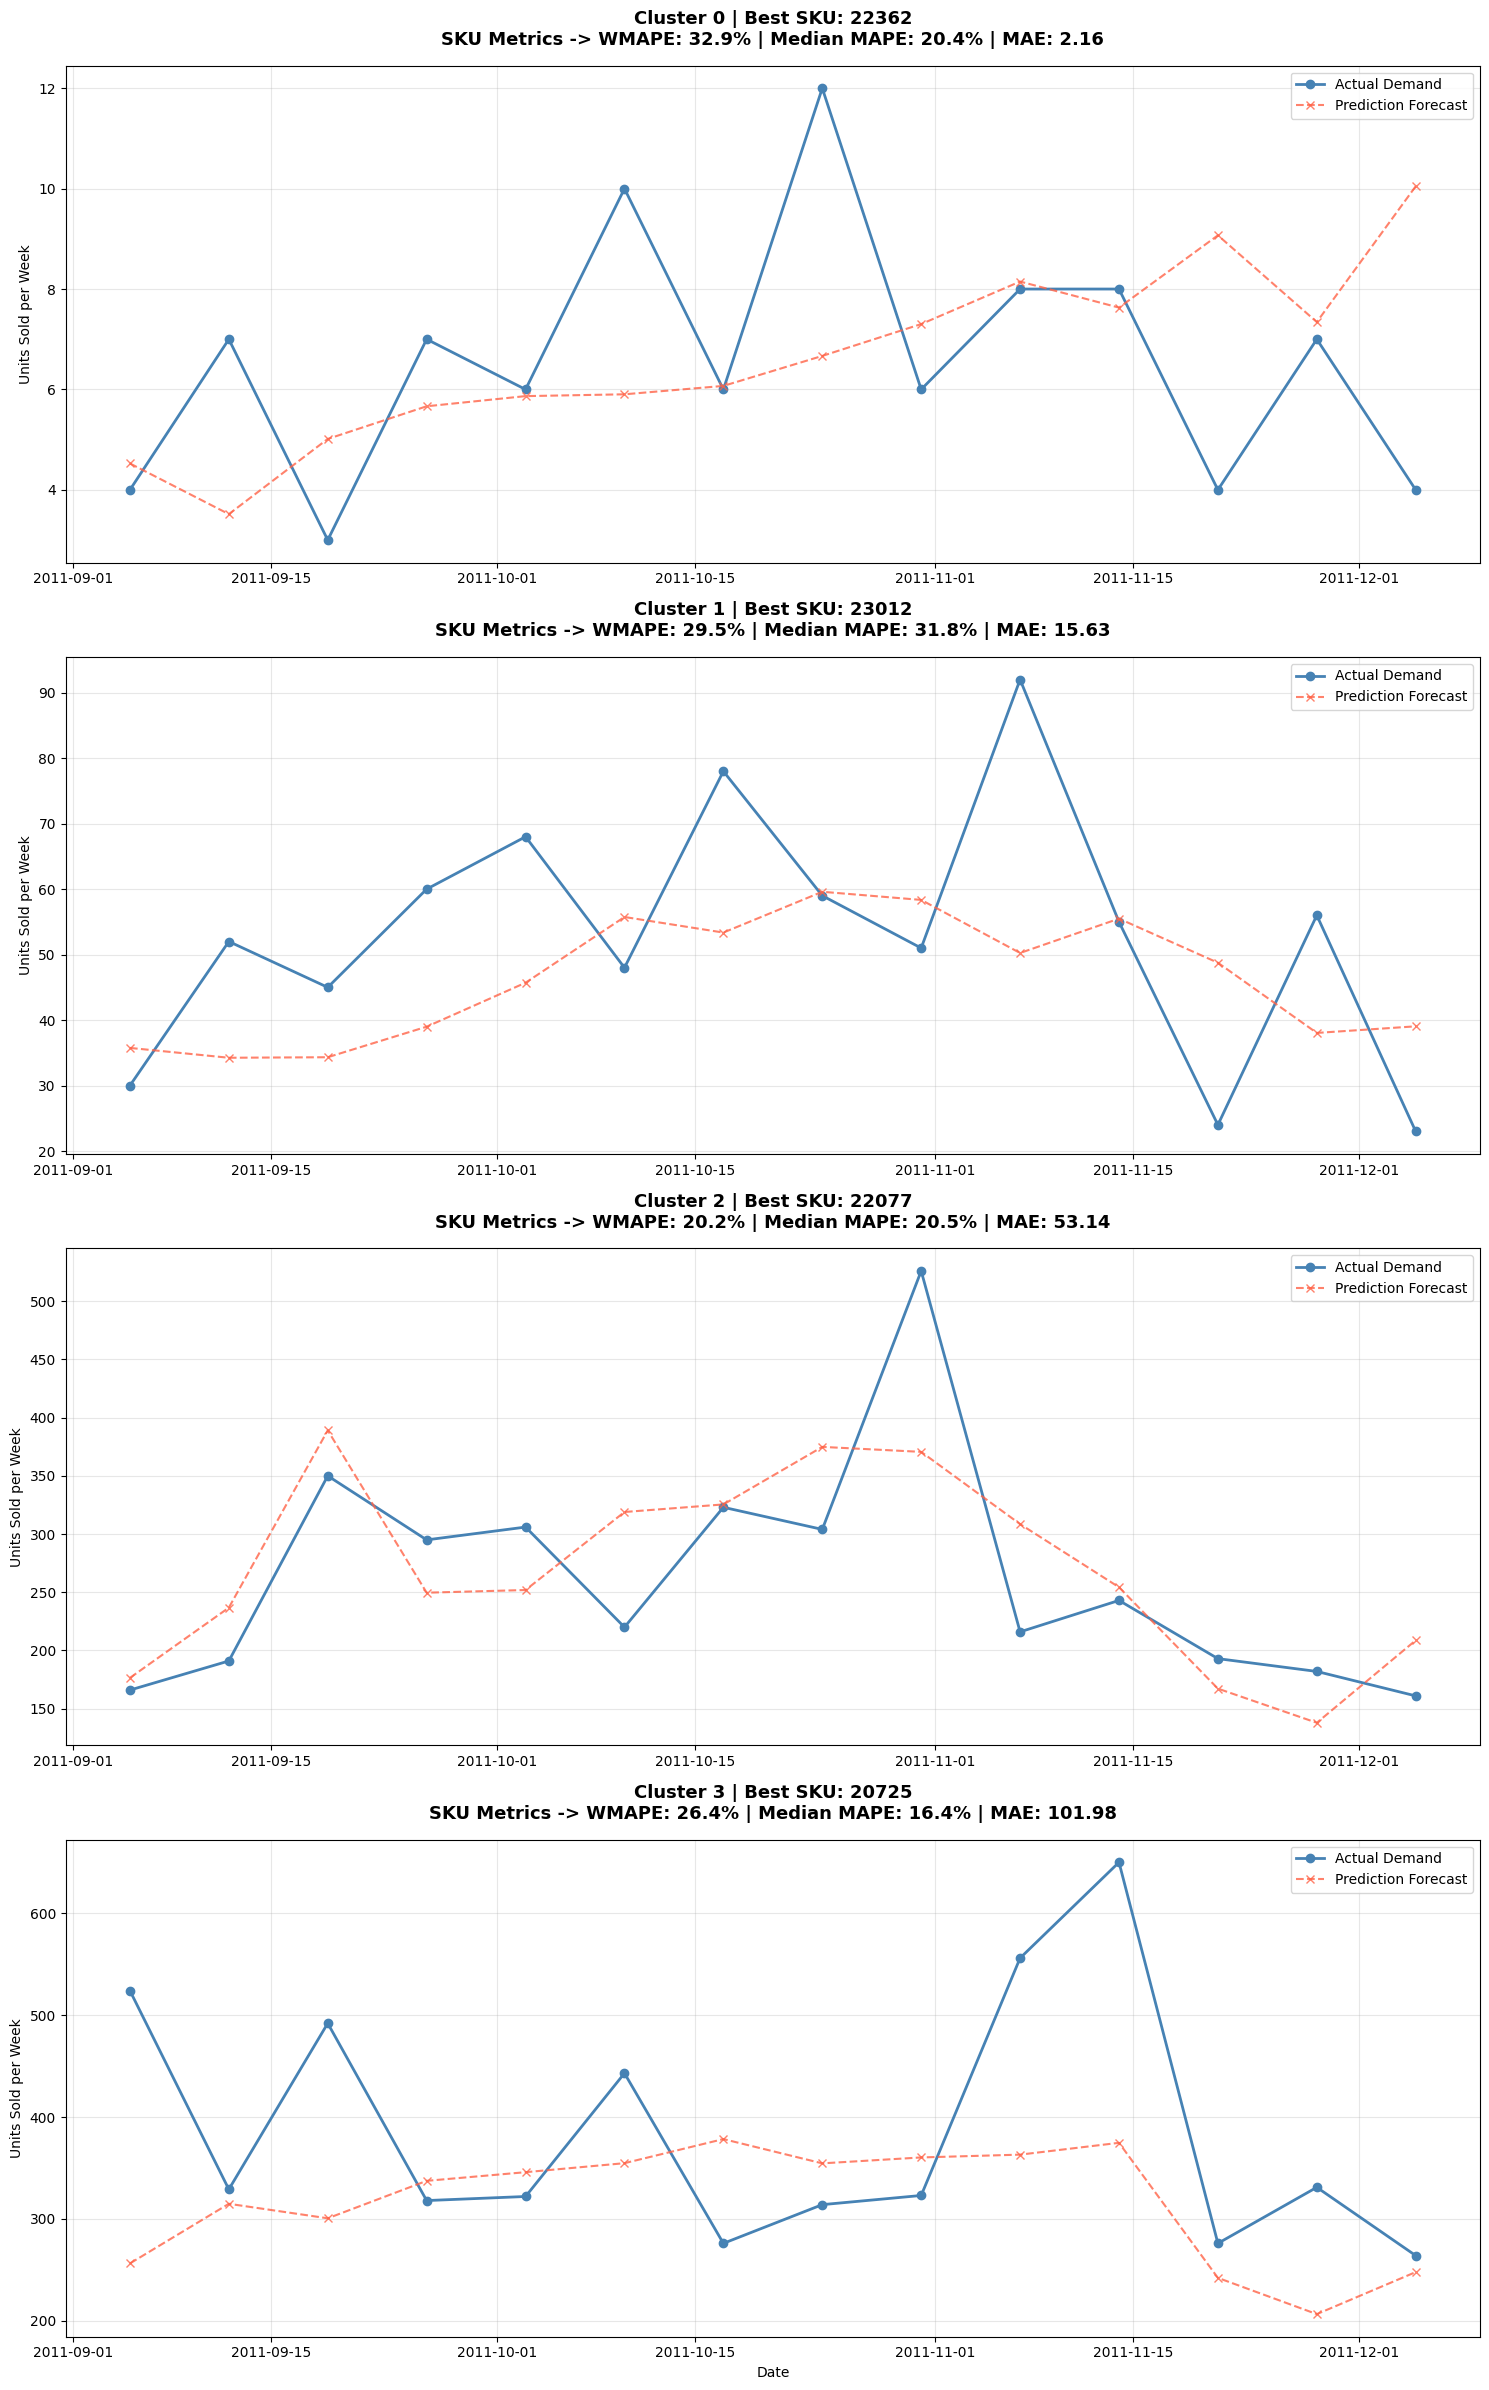

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:188: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_metrics = cluster_eval.groupby("StockCode", observed=True).apply(calc_sku_metrics).dropna()
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning:

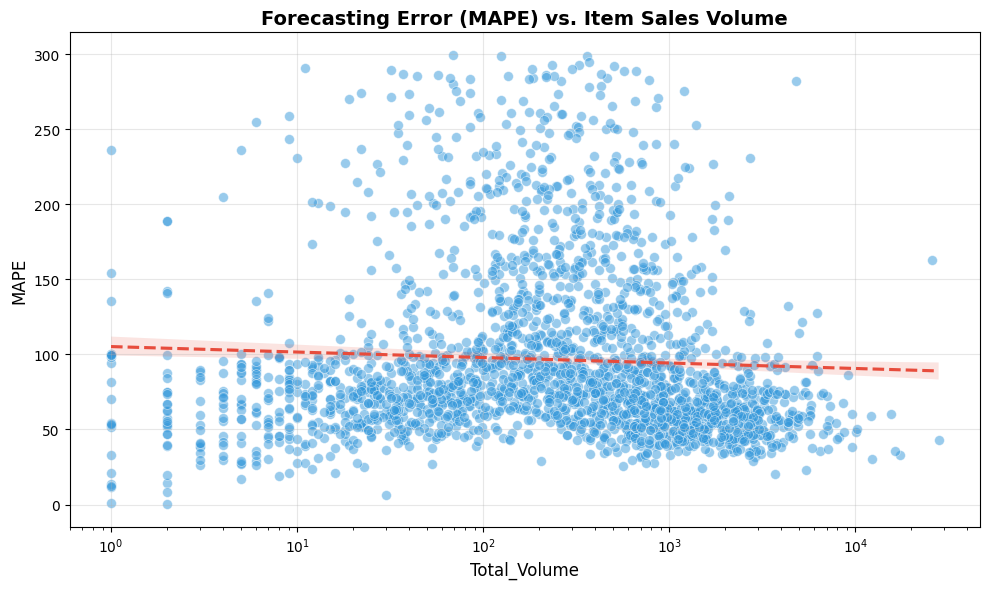

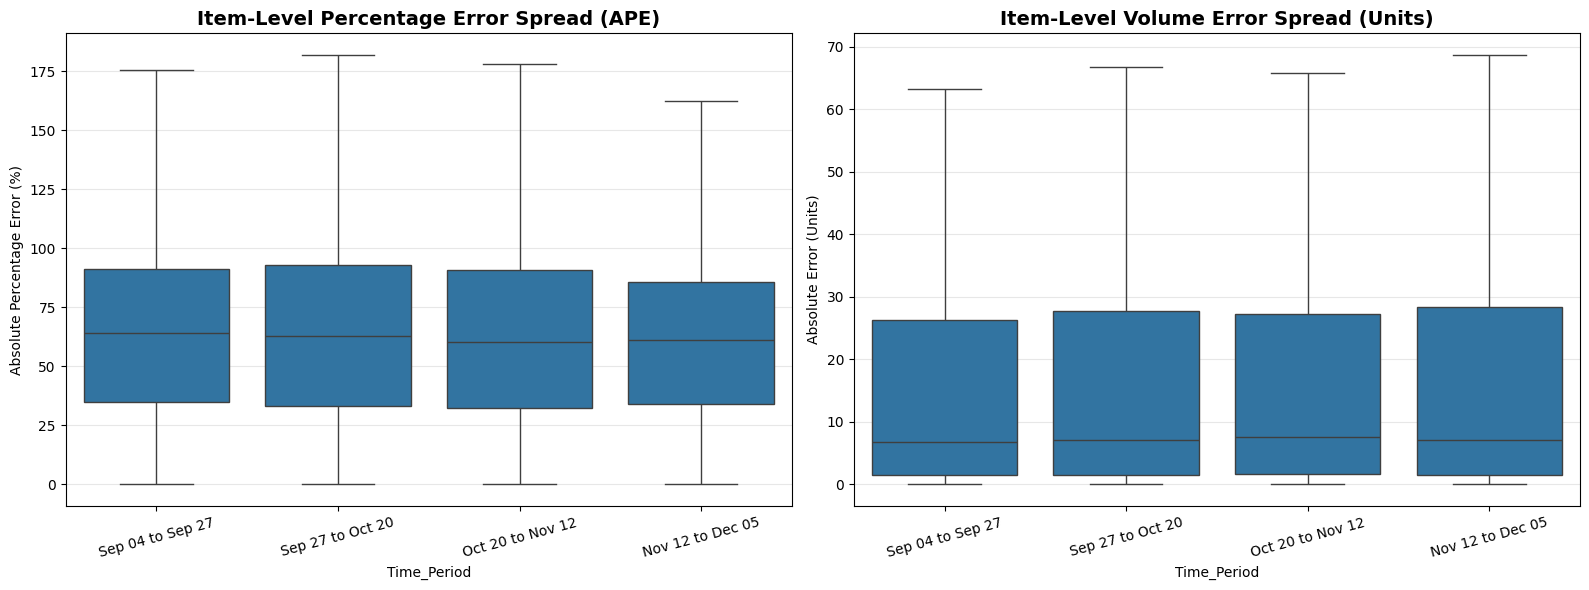

,WMAPE,Median_MAPE,Mean_Absolute_Error
Time_Period,,,
Sep 04 to Sep 27,67.96,64.19,33.41
Sep 27 to Oct 20,65.79,62.90,34.01
Oct 20 to Nov 12,64.99,60.50,37.99
Nov 12 to Dec 05,64.85,61.33,37.80


In [8]:
plot_cluster_portfolio(cluster_eval, summary,)
plot_mape_vs_volume(cluster_eval)

# Analyze the drift of error over time
analyze_time_periods(test)